In [1]:
import pandas as pd

# 1) Path to your dataset
DATA_PATH = "Raw_data_followup_2.csv"   

# 2) Load data
df = pd.read_csv(DATA_PATH)

# 3) List column names
columns = list(df.columns)

# 4) Print them nicely
print("Number of columns:", len(columns))
for col in columns:
    print(col)

Number of columns: 17
participant_id
gender
Submitted_by 
session_number
conversation_initiation
verbal_nonverbal_understanding
peer_interaction_quality
repetitive_behaviour_reduction
changes_adaption
self_care_improvement
task_completion_independence
anxiety_reduction
emotion_expression_Improvement
session_impact_binary
session_impact_valence
therapist_comment
overall_impact_score


In [2]:
outcome_columns = [
    "conversation_initiation",
    "verbal_nonverbal_understanding",
    "peer_interaction_quality",
    "repetitive_behaviour_reduction",
    "changes_adaption",
    "self_care_improvement",
    "task_completion_independence",
    "anxiety_reduction",
    "emotion_expression_Improvement",
    "overall_impact_score",
]


In [3]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
print(missing_summary)

session_impact_valence            10
therapist_comment                  6
conversation_initiation            2
changes_adaption                   1
emotion_expression_Improvement     1
verbal_nonverbal_understanding     1
peer_interaction_quality           1
repetitive_behaviour_reduction     1
self_care_improvement              1
task_completion_independence       1
anxiety_reduction                  1
session_impact_binary              0
participant_id                     0
gender                             0
session_number                     0
Submitted_by                       0
overall_impact_score               0
dtype: int64


In [4]:
missing_percentage = (df.isnull().mean() * 100).round(2)
print(missing_percentage)


participant_id                     0.00
gender                             0.00
Submitted_by                       0.00
session_number                     0.00
conversation_initiation            2.08
verbal_nonverbal_understanding     1.04
peer_interaction_quality           1.04
repetitive_behaviour_reduction     1.04
changes_adaption                   1.04
self_care_improvement              1.04
task_completion_independence       1.04
anxiety_reduction                  1.04
emotion_expression_Improvement     1.04
session_impact_binary              0.00
session_impact_valence            10.42
therapist_comment                  6.25
overall_impact_score               0.00
dtype: float64


In [5]:
df["missing_outcome_fraction"] = df[outcome_columns].isnull().mean(axis=1)

df["missing_outcome_fraction"].describe()


count    96.000000
mean      0.010417
std       0.092314
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.900000
Name: missing_outcome_fraction, dtype: float64

In [6]:
threshold = 0.30

df_clean = df[df["missing_outcome_fraction"] <= threshold].copy()

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))


Rows before cleaning: 96
Rows after cleaning: 95


In [7]:
df_clean = df_clean.drop(columns=["missing_outcome_fraction"])


In [8]:
df_clean.isnull().sum()


participant_id                    0
gender                            0
Submitted_by                      0
session_number                    0
conversation_initiation           1
verbal_nonverbal_understanding    0
peer_interaction_quality          0
repetitive_behaviour_reduction    0
changes_adaption                  0
self_care_improvement             0
task_completion_independence      0
anxiety_reduction                 0
emotion_expression_Improvement    0
session_impact_binary             0
session_impact_valence            9
therapist_comment                 6
overall_impact_score              0
dtype: int64

In [9]:
df_clean.to_csv("dataset_clean_after_missing_handling.csv", index=False)


In [10]:
outcome_columns = [
    "conversation_initiation",
    "verbal_nonverbal_understanding",
    "peer_interaction_quality",
    "repetitive_behaviour_reduction",
    "changes_adaption",
    "self_care_improvement",
    "task_completion_independence",
    "anxiety_reduction",
    "emotion_expression_Improvement",
    "overall_impact_score",
]

In [11]:

for col in outcome_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

In [12]:
invalid_summary = {}

for col in outcome_columns:
    invalid_mask = (df_clean[col] < 0) | (df_clean[col] > 10)
    invalid_count = invalid_mask.sum()
    invalid_summary[col] = invalid_count

invalid_summary

{'conversation_initiation': 0,
 'verbal_nonverbal_understanding': 0,
 'peer_interaction_quality': 0,
 'repetitive_behaviour_reduction': 0,
 'changes_adaption': 0,
 'self_care_improvement': 0,
 'task_completion_independence': 0,
 'anxiety_reduction': 0,
 'emotion_expression_Improvement': 0,
 'overall_impact_score': 0}

In [13]:
df_clean[outcome_columns].describe()


,conversation_initiation,verbal_nonverbal_understanding,peer_interaction_quality,repetitive_behaviour_reduction,changes_adaption,self_care_improvement,task_completion_independence,anxiety_reduction,emotion_expression_Improvement,overall_impact_score
count,94.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,5.053191,5.515789,5.273684,4.778947,5.284211,5.736842,5.873684,5.126316,5.221053,5.800000
std,3.003106,2.953048,2.788434,3.094879,2.735360,2.825456,2.954413,2.877802,3.115435,2.281284
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,3.500000,3.000000,3.000000,3.500000,4.500000,4.000000,3.000000,2.000000,5.000000
50%,5.500000,6.000000,6.000000,5.000000,5.000000,6.000000,6.000000,5.000000,6.000000,6.000000
75%,8.000000,8.000000,7.500000,7.000000,7.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,9.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

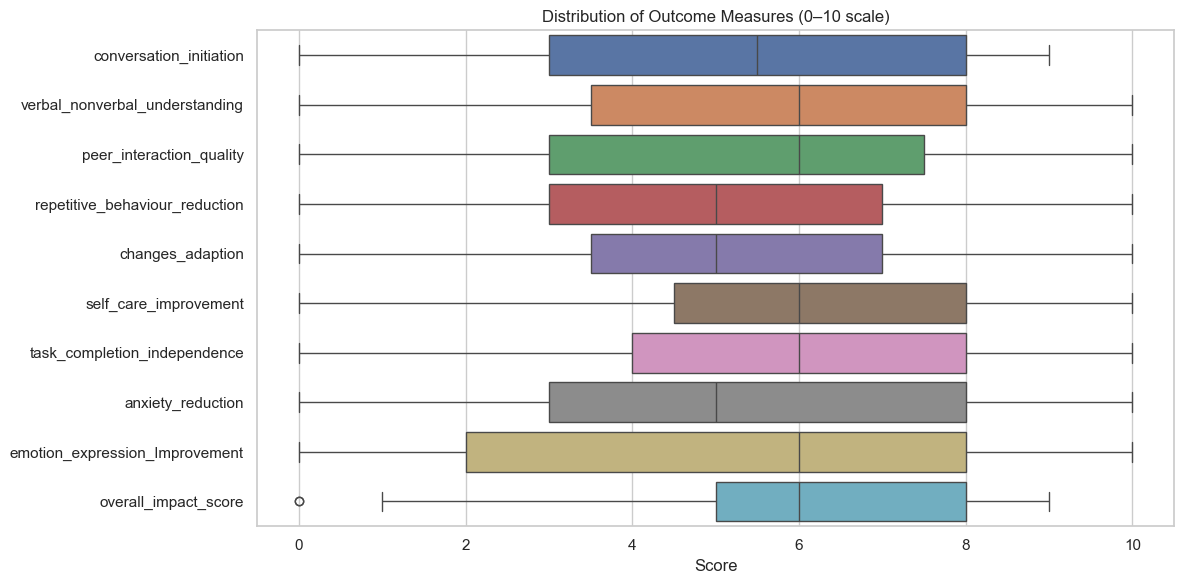

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_clean[outcome_columns],
    orient="h"
)

plt.title("Distribution of Outcome Measures (0–10 scale)")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

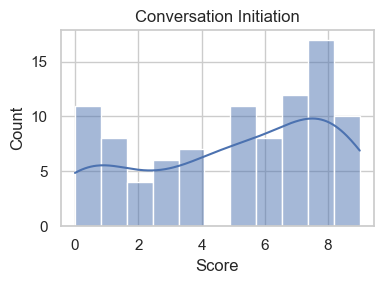

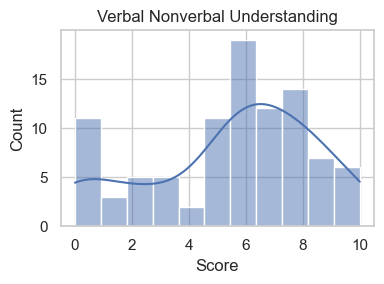

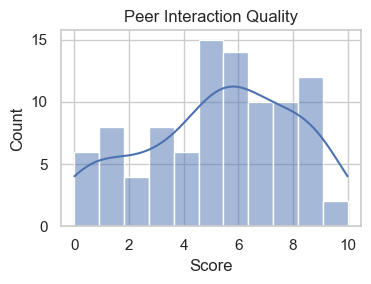

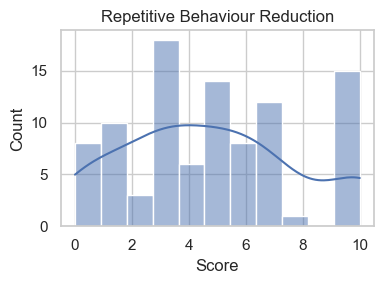

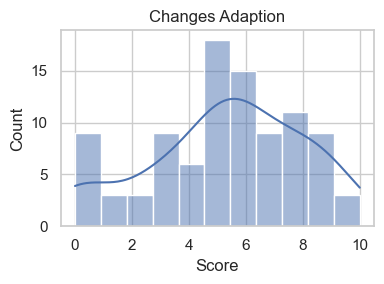

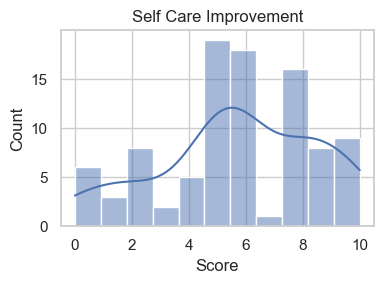

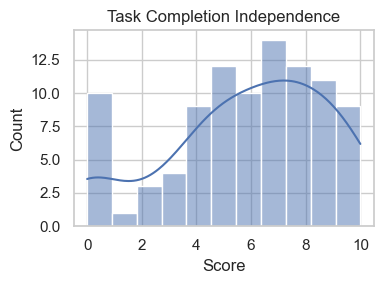

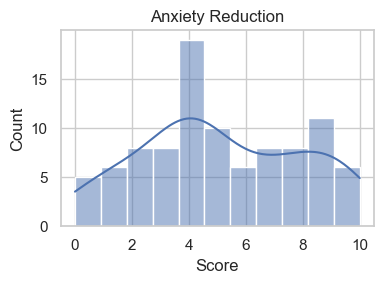

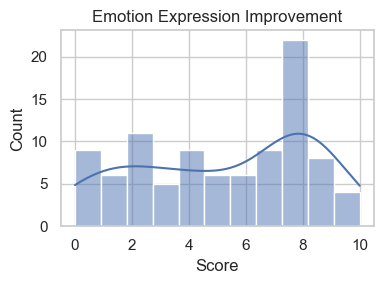

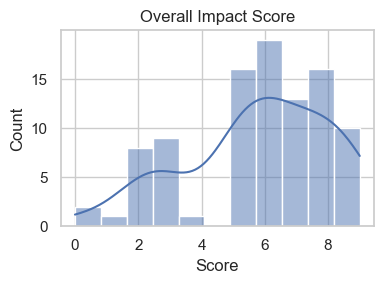

In [18]:
for col in outcome_columns:
    plt.figure(figsize=(4, 3))
    sns.histplot(df_clean[col], bins=11, kde=True)
    plt.title(col.replace("_", " ").title())
    plt.xlabel("Score")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

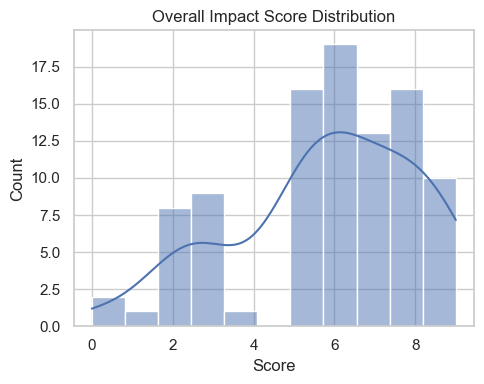

In [20]:
plt.figure(figsize=(5, 4))
sns.histplot(df_clean["overall_impact_score"], bins=11, kde=True)
plt.title("Overall Impact Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

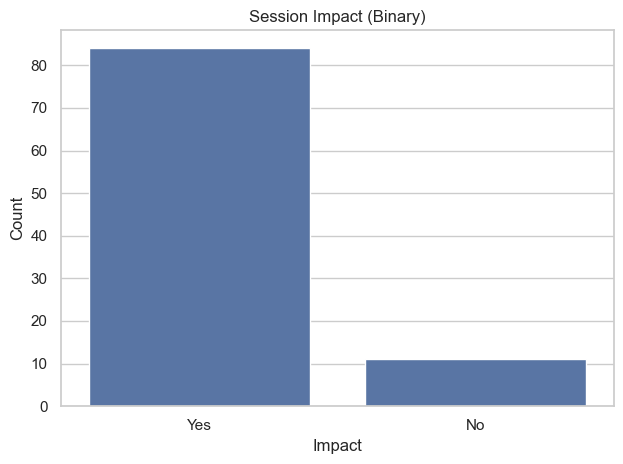

In [21]:
sns.countplot(
    data=df_clean,
    x="session_impact_binary"
)
plt.title("Session Impact (Binary)")
plt.xlabel("Impact")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

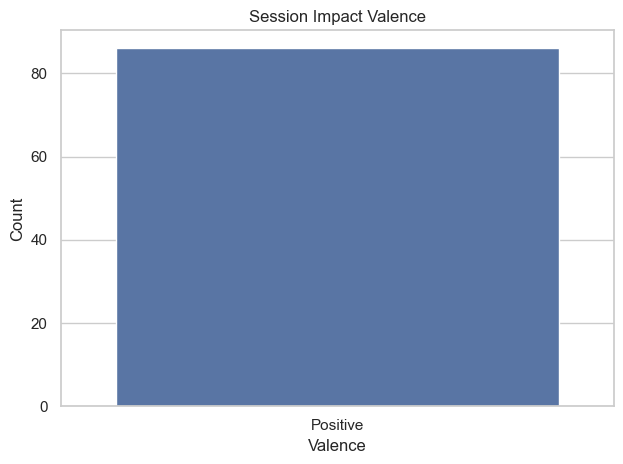

In [22]:
sns.countplot(
    data=df_clean,
    x="session_impact_valence",
    order=df_clean["session_impact_valence"].value_counts().index
)
plt.title("Session Impact Valence")
plt.xlabel("Valence")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


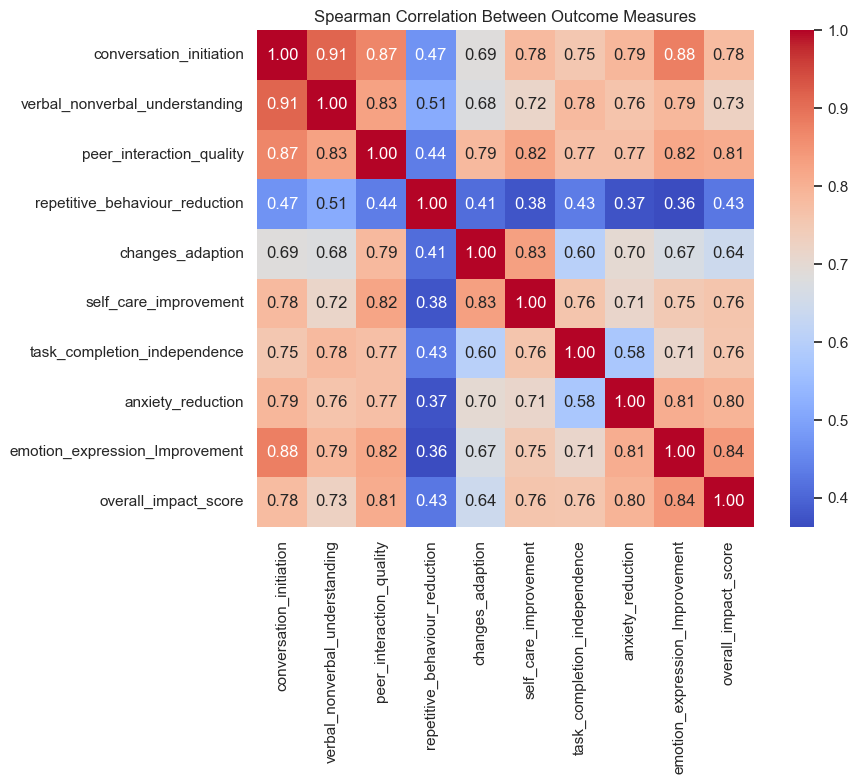

In [23]:
corr = df_clean[outcome_columns].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)
plt.title("Spearman Correlation Between Outcome Measures")
plt.tight_layout()
plt.show()

In [24]:
df_clean["gender"].value_counts(dropna=False)

gender
male      83
Female    12
Name: count, dtype: int64

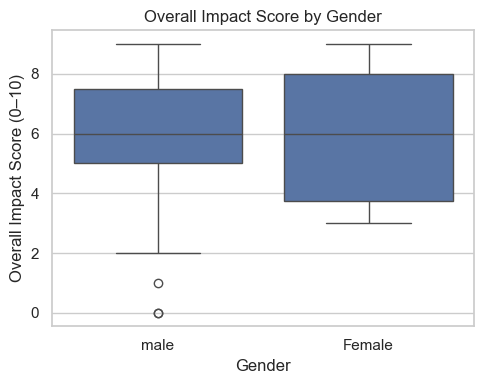

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.boxplot(
    data=df_clean,
    x="gender",
    y="overall_impact_score"
)

plt.title("Overall Impact Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Overall Impact Score (0–10)")
plt.tight_layout()
plt.show()

In [26]:
plot_df = df_clean.melt(
    id_vars="gender",
    value_vars=outcome_columns,
    var_name="outcome",
    value_name="score"
)

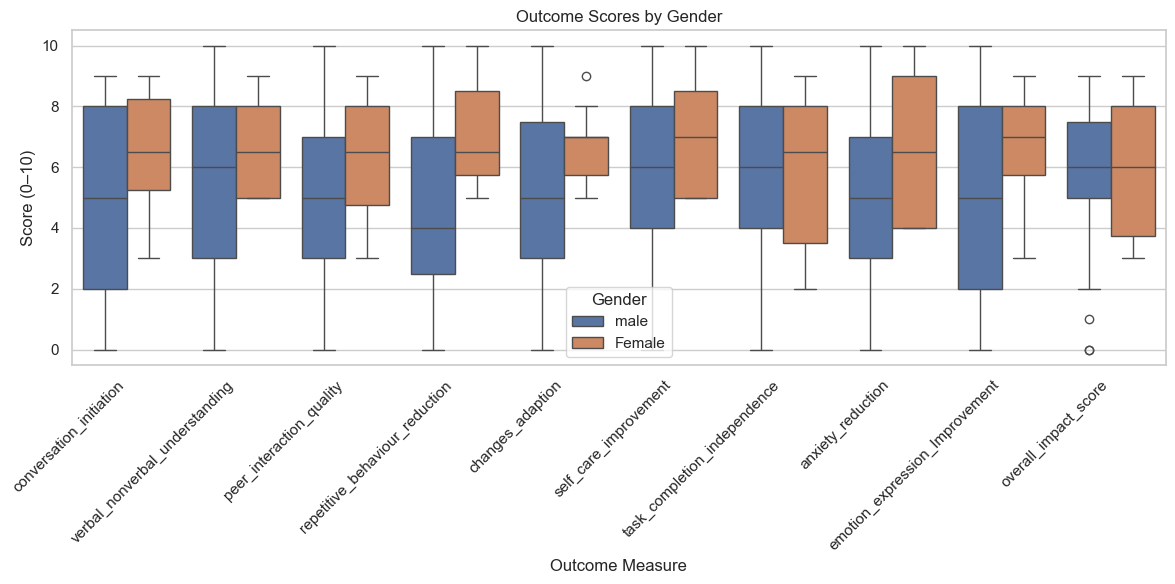

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_df,
    x="outcome",
    y="score",
    hue="gender"
)

plt.xticks(rotation=45, ha="right")
plt.title("Outcome Scores by Gender")
plt.xlabel("Outcome Measure")
plt.ylabel("Score (0–10)")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

In [28]:
df_clean["social_communication_score"] = df_clean[
    [
        "conversation_initiation",
        "verbal_nonverbal_understanding",
        "peer_interaction_quality"
    ]
].mean(axis=1)

df_clean["behaviour_regulation_score"] = df_clean[
    [
        "repetitive_behaviour_reduction",
        "changes_adaption",
        "anxiety_reduction"
    ]
].mean(axis=1)

df_clean["daily_functioning_score"] = df_clean[
    [
        "self_care_improvement",
        "task_completion_independence"
    ]
].mean(axis=1)

df_clean["emotional_skills_score"] = df_clean[
    ["emotion_expression_Improvement"]
].mean(axis=1)

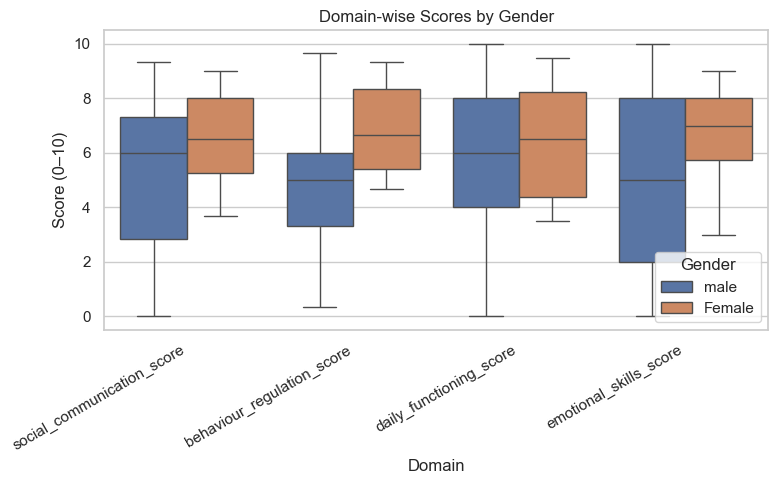

In [29]:
domain_cols = [
    "social_communication_score",
    "behaviour_regulation_score",
    "daily_functioning_score",
    "emotional_skills_score",
]

plot_domain = df_clean.melt(
    id_vars="gender",
    value_vars=domain_cols,
    var_name="domain",
    value_name="score"
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_domain,
    x="domain",
    y="score",
    hue="gender"
)

plt.xticks(rotation=30, ha="right")
plt.title("Domain-wise Scores by Gender")
plt.xlabel("Domain")
plt.ylabel("Score (0–10)")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

In [30]:
total_rows = len(df_clean)
comment_count = df_clean["therapist_comment"].notna().sum()

print(f"Total sessions: {total_rows}")
print(f"Sessions with therapist comments: {comment_count}")
print(f"Percentage with comments: {comment_count / total_rows * 100:.1f}%")

Total sessions: 95
Sessions with therapist comments: 89
Percentage with comments: 93.7%


In [31]:
df_clean["comment_length_words"] = (
    df_clean["therapist_comment"]
    .dropna()
    .str.split()
    .str.len()
)

df_clean["comment_length_words"].describe()

count    89.000000
mean     24.393258
std      14.605897
min       6.000000
25%      16.000000
50%      20.000000
75%      28.000000
max      95.000000
Name: comment_length_words, dtype: float64

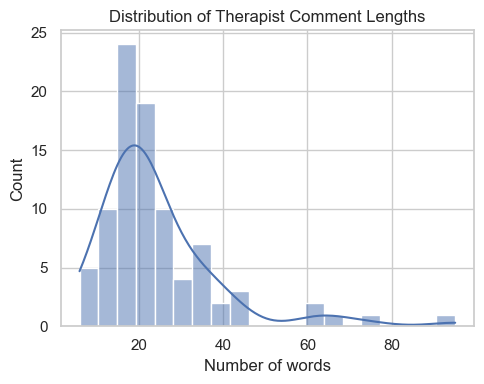

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.histplot(df_clean["comment_length_words"], bins=20, kde=True)
plt.title("Distribution of Therapist Comment Lengths")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [34]:
from textblob import TextBlob
import numpy as np

df_clean["comment_sentiment"] = df_clean["therapist_comment"].apply(
    lambda x: TextBlob(x).sentiment.polarity if pd.notna(x) else np.nan
)

df_clean["comment_sentiment"].describe()

count    89.000000
mean      0.047461
std       0.221236
min      -0.550000
25%      -0.035714
50%       0.000000
75%       0.166667
max       0.600000
Name: comment_sentiment, dtype: float64

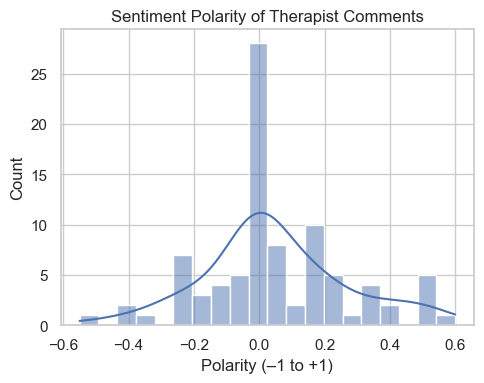

In [35]:
plt.figure(figsize=(5, 4))
sns.histplot(df_clean["comment_sentiment"], bins=20, kde=True)
plt.title("Sentiment Polarity of Therapist Comments")
plt.xlabel("Polarity (–1 to +1)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [37]:
import re

comments = df_clean["therapist_comment"].dropna().str.lower()

tokens = []
for text in comments:
    text = re.sub(r"[^a-z\s]", "", text)
    words = [w for w in text.split() if len(w) > 3]
    tokens.extend(words)

In [38]:
import pandas as pd

word_freq = pd.Series(tokens).value_counts().head(30)
word_freq

final            41
stories          39
comment          38
this             28
with             22
participant      22
improved         17
have             16
that             15
skills           14
anxiety          14
method           13
were             11
intervention     11
them             10
situations       10
story             9
sessions          9
been              9
others            9
high              9
session           9
however           8
performance       8
these             8
repetitive        8
repetition        8
according         8
effectiveness     7
communication     7
Name: count, dtype: int64

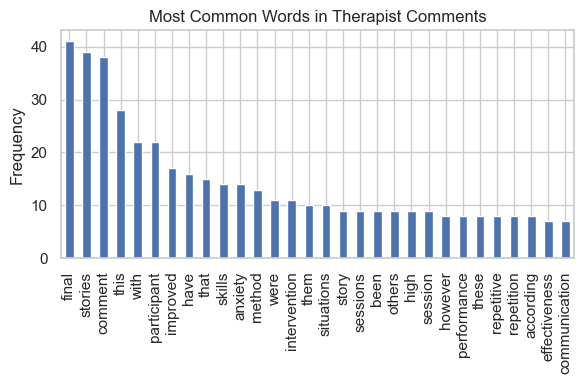

In [39]:
plt.figure(figsize=(6, 4))
word_freq.plot(kind="bar")
plt.title("Most Common Words in Therapist Comments")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [43]:
positive_comments = df_clean[
    df_clean["comment_sentiment"] > 0.1
]["therapist_comment"].dropna()

print("Number of positive comments:", len(positive_comments))

Number of positive comments: 29


In [44]:
import re
from wordcloud import WordCloud, STOPWORDS

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "child", "participant", "session", "today",
    "observed", "showed", "during", "able",
    "also", "within", "using"
])

def clean_text(text_series):
    text = " ".join(text_series).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

positive_text = clean_text(positive_comments)

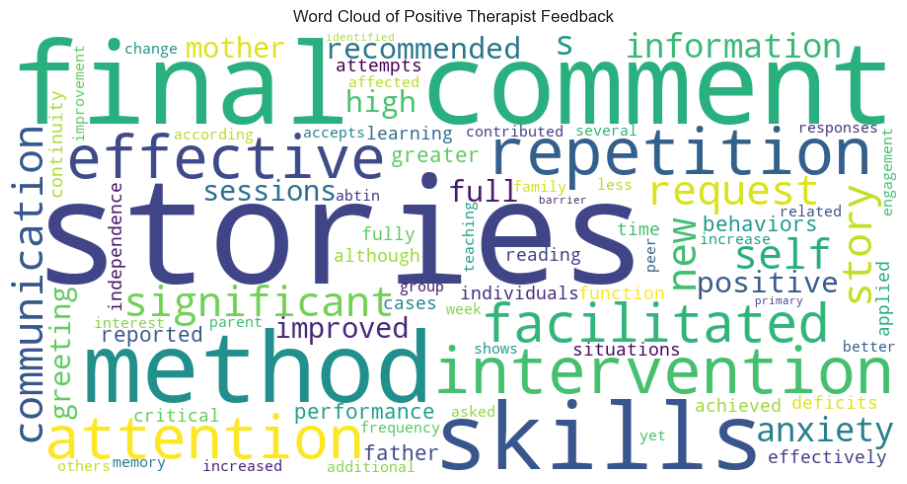

In [45]:
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="viridis",
    max_words=80
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Positive Therapist Feedback")
plt.tight_layout()
plt.show()

In [40]:
themes = {
    "communication": ["talk", "communicat", "verbal", "nonverbal"],
    "emotion_regulation": ["calm", "emotion", "frustrat", "anxious"],
    "social_interaction": ["peer", "group", "interaction"],
    "routine_adaptation": ["routine", "transition", "change"],
}

In [41]:
def detect_theme(text, keywords):
    return any(k in text for k in keywords)

for theme, keywords in themes.items():
    df_clean[f"theme_{theme}"] = df_clean["therapist_comment"].apply(
        lambda x: detect_theme(x.lower(), keywords) if pd.notna(x) else False
    )

In [42]:
theme_cols = [c for c in df_clean.columns if c.startswith("theme_")]
df_clean[theme_cols].sum()

theme_communication         11
theme_emotion_regulation     8
theme_social_interaction    11
theme_routine_adaptation     3
dtype: int64